# Assignment 2

This assignment follows up from the initial exploratory analysis and discussion reported in assignment 1, which reviewed a maternal health dataset, seeking to replicate risk classification to ensure a transparent and usable model for risk assessment. The target variable is Risk Level (High vs Low). Models are evaluated primarily using the F2 score, which places greater emphasis on sensitivity (recall) because failing to identify a high-risk pregnancy is considered clinically more serious than generating additional false positives.

In [1]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, 
    fbeta_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score)
from sklearn import svm, datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import shap
sns.set_theme(style="whitegrid")

In [2]:
# import datasets
train_df = pd.read_csv("./cleaned_train.csv")
val_df = pd.read_csv("./cleaned_validation.csv")
test_df = pd.read_csv("./cleaned_test.csv")


Although for assignment 1, I separated the dataset into separate datasets for training and validation as well as testing, I recondiered and decided to adopt cross validation in order to give a more stable estimate of model performance, due to the relatively small sample size.

The original dataset had already been split into training, validation, and test sets. Missing-value handling and any preprocessing decisions were applied within the training/validation workflow, while the test set remained untouched until final model evaluation.

In [3]:
train_df = pd.read_csv("./cleaned_train.csv")
val_df = pd.read_csv("./cleaned_validation.csv")

target_col = "Risk Level"
risk_map = {"High": 1, "Low": 0}

for df in [train_df, val_df]:
    df[target_col] = df[target_col].map(risk_map)

feature_cols = [c for c in train_df.columns if c != target_col]

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

X_trainval = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_trainval = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

print(y_trainval.value_counts(normalize=True))
print(X_trainval.shape)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Risk Level
0    0.603226
1    0.396774
Name: proportion, dtype: float64
(930, 11)


As above, the merged training + validation dataset has a similar stratification of risk level to the training set.

## Scoring/Evaluation

F2 is a very important metric for evaluating the models, and will be used accross the models, so is defined here before the models.

In [4]:
# beta = 2 -> F2 (not F1 score)
# pos_label=1 means High Risk = 1 is the positive value
f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)

# Naive Prediction

Just for the sake of comparision, as mentioned in Assignment 1, simply predicting everyone as low risk should result in an accuracy level of 60%. Here the confusion matrix is constructed to test that assumption

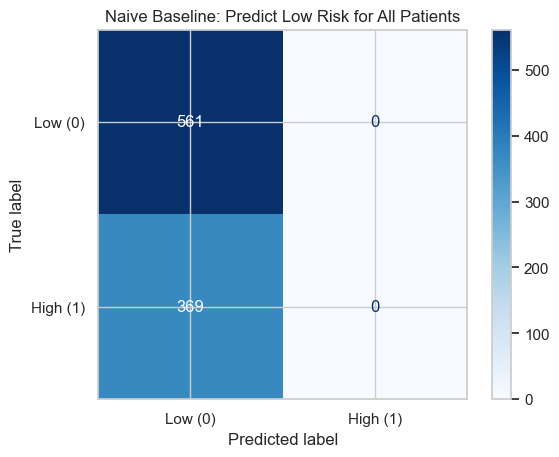

Naive baseline F2 score: 0.0000


In [5]:
y_naive_pred = np.zeros_like(y_trainval)

cm = confusion_matrix(y_trainval, y_naive_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low (0)', 'High (1)'])
disp.plot(cmap='Blues')
plt.title('Naive Baseline: Predict Low Risk for All Patients')
plt.show()

naive_f2 = fbeta_score(y_trainval, y_naive_pred, beta=2, pos_label=1)
print(f"Naive baseline F2 score: {naive_f2:.4f}")

So any F2 score above 0 will be an improvement, and can be assessed for significance.

## Baseline Model: Logistic Regression

This is a logistic regression model. In contrast to the tree based models, here scaling is vitally important with different features having very different scales. The pipeline is as follows: raw data -> scaling -> logistic regression -> predictions.

Note in the parameter grid below, the clf__penalty choses to use lasso first and then ridge as there is some moderate multicolinearity (e.g. Mental Health and Previous Complications and/or Preexisting Diabetes). If Mental Health's contribution really is mostly redundant once the other two are accounted for, l1 regularisation may zero out its coefficient entirely during fitting, keeping only features that add genuinely independent predictive value.

In [6]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(solver='liblinear', max_iter=1000, random_state=42))
])

parameter_grid = {
    'clf__C': [0.01, 0.1, 1, 10, 100], # controls regularisation strength, smaller means simpler model
    'clf__penalty': ['l1', 'l2'], # l1 = lasso, l2 = ridge
    'clf__class_weight': ['balanced', None]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=parameter_grid,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

grid_search.fit(X_trainval, y_trainval)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.01, 0.1, ...], 'clf__class_weight': ['balanced', None], 'clf__penalty': ['l1', 'l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","make_scorer(f..., pos_label=1)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will o

In [7]:
best_model = grid_search.best_estimator_
coefs = best_model.named_steps['clf'].coef_[0]
feature_names = X_trainval.columns

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df = coef_df.sort_values('coefficient', key=abs, ascending=False)
print(coef_df)

                   feature  coefficient
7     Preexisting Diabetes     1.582736
8     Gestational Diabetes     1.231714
9            Mental Health     0.883697
3                       BS     0.732465
10              Heart Rate     0.709093
6   Previous Complications     0.691067
5                      BMI     0.553082
2                Diastolic     0.426831
0                      Age    -0.389448
4                Body Temp     0.320348
1              Systolic BP     0.316451


The top three features identified in this logistic regression model are Preexisting Diabetes, Gestational Diabetes, and Mental Health. The first two were expected from the exploratory analysis, but Mental Health was not so anticipated. Another item to note is the apparent negative effect of age, which again is not so clinically plausible. These two findings therefore suggest that there is multicollinearity between correlated binary predictors, which can inflate or destabilise individual coefficient estimates in logistic regression. This indicates that a stable, interpretable reading of coefficients may be limited in this model, and motivates comparison against the tree-based models.

However, as identified in Assignment 1, the Cramers V values do not suggest strong multicolinearity between Mental Health and other binary features. It is therefore important to consider the VIF scores to assess the multicolinearity and determine the suitability of this as a final model.

In [8]:
X_vif = X_trainval.copy()
X_vif_const = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]

vif_data = vif_data[vif_data['Feature'] != 'const']
print(vif_data.sort_values('VIF', ascending=False))

                   Feature       VIF
2              Systolic BP  2.881665
3                Diastolic  2.808364
4                       BS  2.617031
8     Preexisting Diabetes  1.710841
1                      Age  1.669357
6                      BMI  1.584144
10           Mental Health  1.511734
7   Previous Complications  1.447775
9     Gestational Diabetes  1.322787
11              Heart Rate  1.234777
5                Body Temp  1.146648


In [9]:
print("Best parameters:", grid_search.best_params_)
print("Best CV score (F2):", grid_search.best_score_)

Best parameters: {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2'}
Best CV score (F2): 0.9696185058306501


This model achieved a very high cross-validated F2 score of 0.9696. While this implicitly suggests a strong predictive power, it is consistent with the possibility that the target variable is strongly determined by a small subset of predictors.

In [10]:
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values('mean_test_score', ascending=False)

results_df[['params', 'mean_test_score', 'std_test_score', 'mean_train_score']].head(10)

,params,mean_test_score,std_test_score,mean_train_score
5,"{'clf__C': 0.1, 'clf__class_weight': 'balanced...",0.969619,0.011255,0.971772
8,"{'clf__C': 1, 'clf__class_weight': 'balanced',...",0.969091,0.011021,0.975166
17,"{'clf__C': 100, 'clf__class_weight': 'balanced...",0.969088,0.012408,0.975150
16,"{'clf__C': 100, 'clf__class_weight': 'balanced...",0.969088,0.012408,0.975150
12,"{'clf__C': 10, 'clf__class_weight': 'balanced'...",0.969088,0.012408,0.974606
13,"{'clf__C': 10, 'clf__class_weight': 'balanced'...",0.969088,0.012408,0.975562
9,"{'clf__C': 1, 'clf__class_weight': 'balanced',...",0.968566,0.011808,0.974888
4,"{'clf__C': 0.1, 'clf__class_weight': 'balanced...",0.967026,0.011265,0.968851
7,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl...",0.962233,0.022821,0.964924
6,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl...",0.959797,0.018585,0.964817


## Model 2: Single Tree Model

Note that the single tree model provides several benefits over logistic regression. It allows for a very clear and potentially visual interpretation/replication of the rule-generated risk model, which can transparently show every split it chooses.

It is also unnecessary to scale in a single tree model, as thresholds are based on the features own ranges.

In [11]:
pipeline_tree = Pipeline([
    ('clf', DecisionTreeClassifier(random_state=42))
])

parameter_grid_tree = {
    'clf__max_depth': [2, 3, 4, 5, None],
    'clf__min_samples_leaf': [1, 5, 10, 20],
    'clf__criterion': ['gini', 'entropy'],
    'clf__class_weight': ['balanced', None]
}

grid_search_tree = GridSearchCV(
    estimator=pipeline_tree,
    param_grid=parameter_grid_tree,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

grid_search_tree.fit(X_trainval, y_trainval)

print("Best parameters:", grid_search_tree.best_params_)
print("Best CV score (F2):", grid_search_tree.best_score_)

Best parameters: {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_leaf': 1}
Best CV score (F2): 0.9615938034042728


This model which is considered the 'best' has the minimum leaf size of 1, which would imply fitting to individual outlier patient(s). In order to interrogate this further, it is useful to review the difference in performance between the training data and the validation data.

In [12]:
results_df = pd.DataFrame(grid_search_tree.cv_results_)
best_row = results_df.loc[results_df['mean_test_score'].idxmax()]
print("Mean train score:", best_row['mean_train_score'])
print("Mean test (val) score:", best_row['mean_test_score'])
print("Std test score:", best_row['std_test_score'])

Mean train score: 1.0
Mean test (val) score: 0.9615938034042728
Std test score: 0.015649269917599715


As can be seen above, there is a difference between the performance with the training and validation data, which indicates evidence of overfitting.

In [13]:
results_df_sorted = results_df.sort_values('mean_test_score', ascending=False)
print(results_df_sorted[['params', 'mean_test_score', 'std_test_score', 'mean_train_score']].head(10))

                                               params  mean_test_score  \
16  {'clf__class_weight': 'balanced', 'clf__criter...         0.961594   
12  {'clf__class_weight': 'balanced', 'clf__criter...         0.955044   
56  {'clf__class_weight': None, 'clf__criterion': ...         0.953958   
36  {'clf__class_weight': 'balanced', 'clf__criter...         0.952751   
17  {'clf__class_weight': 'balanced', 'clf__criter...         0.950264   
13  {'clf__class_weight': 'balanced', 'clf__criter...         0.949842   
76  {'clf__class_weight': None, 'clf__criterion': ...         0.948832   
18  {'clf__class_weight': 'balanced', 'clf__criter...         0.948223   
14  {'clf__class_weight': 'balanced', 'clf__criter...         0.948223   
32  {'clf__class_weight': 'balanced', 'clf__criter...         0.946419   

    std_test_score  mean_train_score  
16        0.015649          1.000000  
12        0.013044          0.983891  
56        0.019966          1.000000  
36        0.027791          1

In [14]:
pd.set_option('display.max_colwidth', None)
print(results_df_sorted[['params', 'mean_test_score', 'mean_train_score']].head(10).to_string())

                                                                                                                params  mean_test_score  mean_train_score
16     {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_leaf': 1}         0.961594          1.000000
12        {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_leaf': 1}         0.955044          0.983891
56           {'clf__class_weight': None, 'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_leaf': 1}         0.953958          1.000000
36  {'clf__class_weight': 'balanced', 'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__min_samples_leaf': 1}         0.952751          1.000000
17     {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_leaf': 5}         0.950264          0.981166
13        {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__

In [15]:
shallow_results = results_df[results_df['params'].apply(lambda p: p['clf__max_depth'] in [2, 3])]
shallow_results_sorted = shallow_results.sort_values('mean_test_score', ascending=False)
print(shallow_results_sorted[['params', 'mean_test_score', 'mean_train_score']].head(10).to_string())

                                                                                                           params  mean_test_score  mean_train_score
5    {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_leaf': 5}         0.924322          0.937605
6   {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_leaf': 10}         0.924322          0.937655
7   {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_leaf': 20}         0.922676          0.937920
4    {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_leaf': 1}         0.922152          0.938407
47        {'clf__class_weight': None, 'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_leaf': 20}         0.897895          0.906628
45         {'clf__class_weight': None, 'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_le

It is interesting to note the overall pattern here. There is a substantial difference in performance between different depths. A depth of 2 shows a validation performance of only 0.873 at best, while the best performance with a depth of 3 is 0.924. There continues to be an improvement as depth increases, with depth = 5 gets to 0.948, but this difference between a depth of 3 and a depth of 5 is not substantial, and therefore a more parsimonious model is preferred. A shallow tree is preferred because it provides a simpler decision rule that is easier for clinicians to inspect and potentially implement. 

At a depth of 3, there is equivalent performance with minimum leaf size of 5 or 10, so for the final model the minimum leaf size of 10 was chosen to reduce the risk of overfitting.

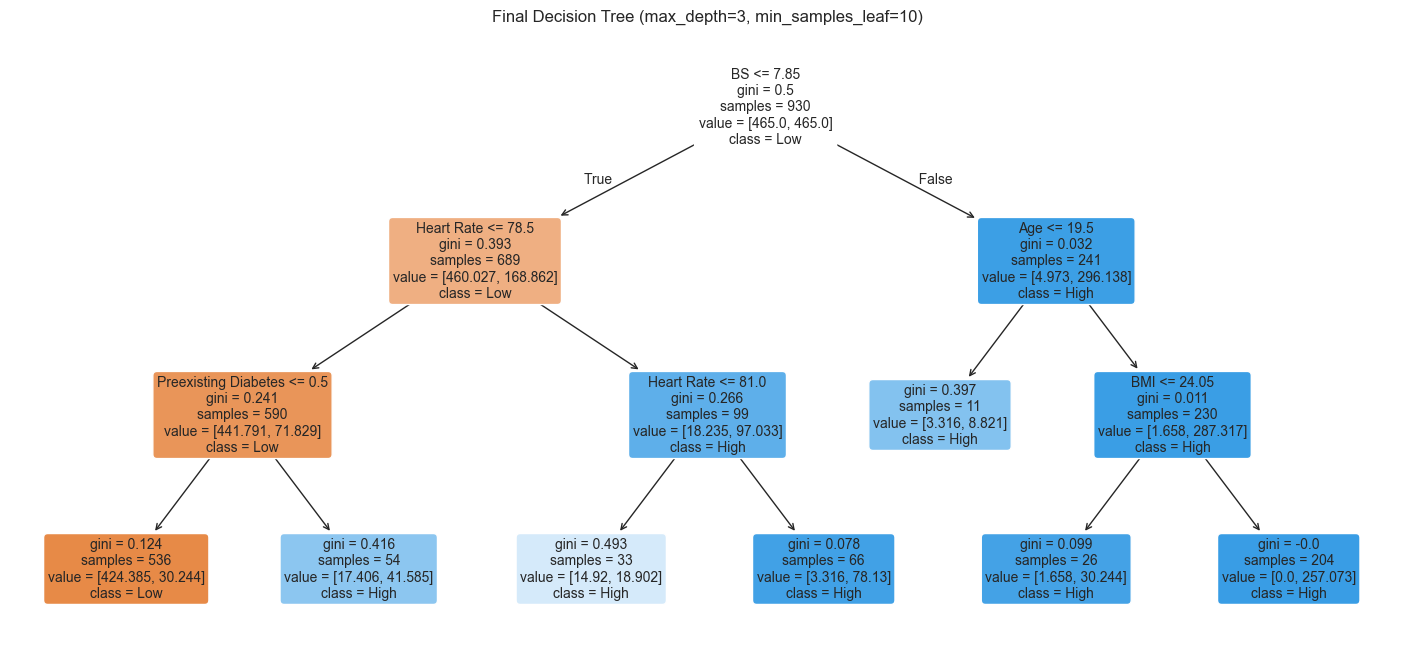

In [16]:
final_tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=10,
    criterion='gini',
    class_weight='balanced',
    random_state=42
)

final_tree.fit(X_trainval, y_trainval)

plt.figure(figsize=(18, 8))
plot_tree(
    final_tree,
    feature_names=X_trainval.columns,
    class_names=['Low', 'High'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Final Decision Tree (max_depth=3, min_samples_leaf=10)')
plt.show()

In [17]:
print(export_text(final_tree, feature_names=list(X_trainval.columns)))

|--- BS <= 7.85
|   |--- Heart Rate <= 78.50
|   |   |--- Preexisting Diabetes <= 0.50
|   |   |   |--- class: 0
|   |   |--- Preexisting Diabetes >  0.50
|   |   |   |--- class: 1
|   |--- Heart Rate >  78.50
|   |   |--- Heart Rate <= 81.00
|   |   |   |--- class: 1
|   |   |--- Heart Rate >  81.00
|   |   |   |--- class: 1
|--- BS >  7.85
|   |--- Age <= 19.50
|   |   |--- class: 1
|   |--- Age >  19.50
|   |   |--- BMI <= 24.05
|   |   |   |--- class: 1
|   |   |--- BMI >  24.05
|   |   |   |--- class: 1



Contrary to expectations, the root split was on Blood Sugar (BS ≤ 7.85) rather than one of the Diabetes binary features. It is clinically plausible that this reflects blood sugar levels being closely linked to diabetes diagnosis and so this hypothesis is tested directly via point-biserial correlation.

In [18]:
r, p = stats.pointbiserialr(df['Gestational Diabetes'], df['BS'])
print(f"BS vs Gestational Diabetes: r = {r:.3f}, p = {p:.4f}")
r, p = stats.pointbiserialr(df['Preexisting Diabetes'], df['BS'])
print(f"BS vs Prexisting Diabetes: r = {r:.3f}, p = {p:.4f}")

BS vs Gestational Diabetes: r = 0.049, p = 0.4572
BS vs Prexisting Diabetes: r = 0.623, p = 0.0000


Blood Sugar and Preexisting Diabetes show a moderate-to-strong correlation (r=0.623, p<0.0001), suggesting shared but non-redundant information, consistent with preexisting diabetes typically presenting as consistently and chronically high blood sugar. 

This is corroborated by the decision tree's structure, where Preexisting Diabetes provides a further split within the low BS subgroup. It therefore retains discriminating power beyond what BS alone captures. 

It is possible and indeed probable that this BS value is a singular reading, but it is not specifically explained as such in the documentation for the dataset. Gestational Diabetes shows very low correlation with BS (r=0.049, p=0.457) despite gestational diabetes being diagnosed via blood sugar testing. This discrepancy could not be resolved from the available data and may reflect how BS was measured in this dataset. 

## Model 3: Random Forest Model

Random Forest extends a single decision tree by averaging predictions across many trees built from bootstrap samples and random subsets of features. This typically reduces variance and overfitting while retaining the ability to model nonlinear relationships and interactions between predictors.

The parameter grid for the Random Forest model was informed by the earlier single decision-tree model. As the single tree achieved its best validation performance with a shallow depth (3) and relatively large minimum leaf size (10), the Random Forest search was restricted to nearby values (depths 3–5 and leaf sizes 5–10). This reduced computational cost and retained the explainability benefits described above.

In [19]:
pipeline_rf = Pipeline([
    ('clf', RandomForestClassifier(random_state=42))
])

parameter_grid_rf = {
    'clf__n_estimators': [100, 300, 500, 1000],
    'clf__max_depth': [3, 5],
    'clf__min_samples_leaf': [5, 10],
    'clf__max_features': ['sqrt'],
    'clf__class_weight': ['balanced']
}

In [20]:
grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=parameter_grid_rf,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_search_rf.fit(X_trainval, y_trainval)
best_rf = grid_search_rf.best_estimator_

In [21]:
print("Best RF parameters:", grid_search_rf.best_params_)
print("Best RF CV F2:", grid_search_rf.best_score_)

Best RF parameters: {'clf__class_weight': 'balanced', 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 10, 'clf__n_estimators': 500}
Best RF CV F2: 0.9811929423054749


This Random Forest model achieved a very F2 score (0.9812), indicating excellent performance on the available dataset. Nevertheless, the result should be interpreted cautiously because the dataset is relatively small and as already mentioned, risk level may be strongly determined by a limited number of features.

In [22]:
results_rf = pd.DataFrame(grid_search_rf.cv_results_)
best_rf_row = results_rf.loc[results_rf['mean_test_score'].idxmax()]

print('Mean train F2:', best_rf_row['mean_train_score'])
print('Mean CV F2:', best_rf_row['mean_test_score'])
print('Std CV F2:', best_rf_row['std_test_score'])

Mean train F2: 0.985326046254779
Mean CV F2: 0.9811929423054749
Std CV F2: 0.0033315769208113527


The difference between test F2 values for training data versus validation data was only 0.004, indicating minimal evidence of overfitting. The standard deviation of the cross-validated F2 score was 0.003, demonstrating consistent performance across the validation folds.

In [23]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Mean_F2': [
        grid_search.best_score_,
        grid_search_tree.best_score_,
        grid_search_rf.best_score_
    ],
    'Std_F2': [
        grid_search.cv_results_['std_test_score'][grid_search.best_index_],
        grid_search_tree.cv_results_['std_test_score'][grid_search_tree.best_index_],
        grid_search_rf.cv_results_['std_test_score'][grid_search_rf.best_index_]
    ]
})

print(comparison_df)

                 Model   Mean_F2    Std_F2
0  Logistic Regression  0.969619  0.011255
1        Decision Tree  0.961594  0.015649
2        Random Forest  0.981193  0.003332


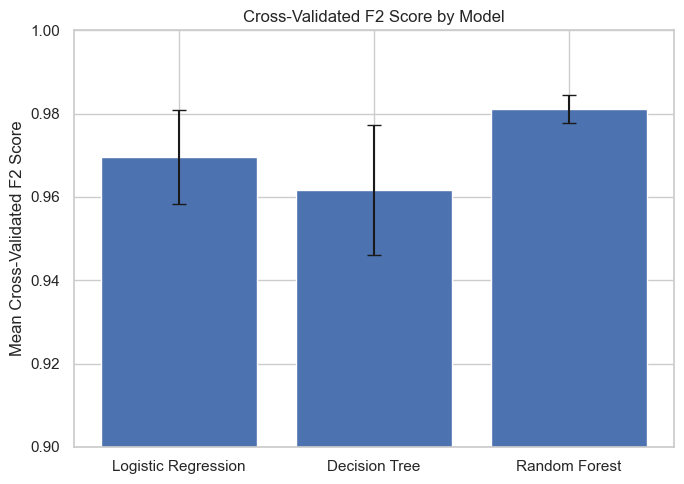

In [24]:
plt.figure(figsize=(7,5))

plt.bar(
    comparison_df['Model'],
    comparison_df['Mean_F2'],
    yerr=comparison_df['Std_F2'],
    capsize=5
)

plt.ylabel('Mean Cross-Validated F2 Score')
plt.ylim(0.9, 1.0)
plt.title('Cross-Validated F2 Score by Model')

plt.tight_layout()
plt.show()

As can be seen, random forest performs most strongly based on mean cross-validated F2 score, as well as having a smaller variance.

                 Model  Train_F2     CV_F2
0  Logistic Regression  0.971772  0.969619
1        Decision Tree  1.000000  0.961594
2        Random Forest  0.985326  0.981193


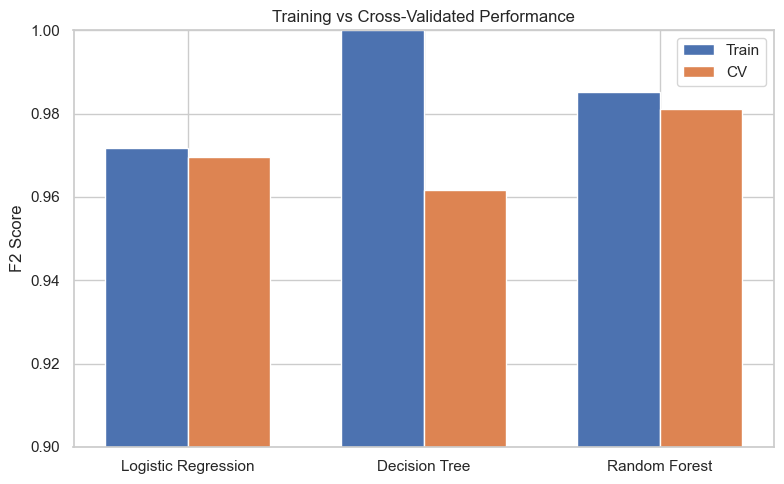

In [25]:
overfit_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Train_F2': [
        grid_search.cv_results_['mean_train_score'][grid_search.best_index_],
        grid_search_tree.cv_results_['mean_train_score'][grid_search_tree.best_index_],
        grid_search_rf.cv_results_['mean_train_score'][grid_search_rf.best_index_]
    ],
    'CV_F2': [
        grid_search.best_score_,
        grid_search_tree.best_score_,
        grid_search_rf.best_score_
    ]
})

print(overfit_df)

x = np.arange(len(overfit_df))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, overfit_df['Train_F2'], width, label='Train')
plt.bar(x + width/2, overfit_df['CV_F2'], width, label='CV')

plt.xticks(x, overfit_df['Model'])
plt.ylabel('F2 Score')
plt.ylim(0.9, 1.0)
plt.title('Training vs Cross-Validated Performance')
plt.legend()
plt.tight_layout()
plt.show()

# Final tests with testing dataset

In [26]:
test_df = pd.read_csv("cleaned_test.csv")

X_test = test_df[feature_cols]
y_test = test_df["Risk Level"]

risk_map = {'Low': 0, 'High': 1}
y_test = y_test.map(risk_map)

print(y_test.unique())

[0 1]


In [27]:
y_pred_rf = best_rf.predict(X_test)
y_pred_tree = final_tree.predict(X_test)
y_pred_lr = best_model.predict(X_test)

def evaluate_model(name, y_true, y_pred):
    print(f"\n--- {name} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.3f}")
    print(f"F1 Score : {f1_score(y_true, y_pred):.3f}")
    print(f"F2 Score : {fbeta_score(y_true, y_pred, beta=2):.3f}")

evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Single Tree", y_test, y_pred_tree)
evaluate_model("Random Forest", y_test, y_pred_rf)


--- Logistic Regression ---
Accuracy : 0.966
Precision: 0.968
Recall   : 0.947
F1 Score : 0.957
F2 Score : 0.951

--- Single Tree ---
Accuracy : 0.890
Precision: 0.822
Recall   : 0.926
F1 Score : 0.871
F2 Score : 0.903

--- Random Forest ---
Accuracy : 0.979
Precision: 0.969
Recall   : 0.979
F1 Score : 0.974
F2 Score : 0.977


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


These values are consistent with the findings from the cross-validation training set. The Random Forest model has the highest F2 score, as well as the highest metrics for accuracy, precision (albeit only marginally better than logistic regression), recall and F1 score.

Logistic regression also performs strongly. Depending on the weight that is put on transparency, this may be a more persuasive choice for explanability. 

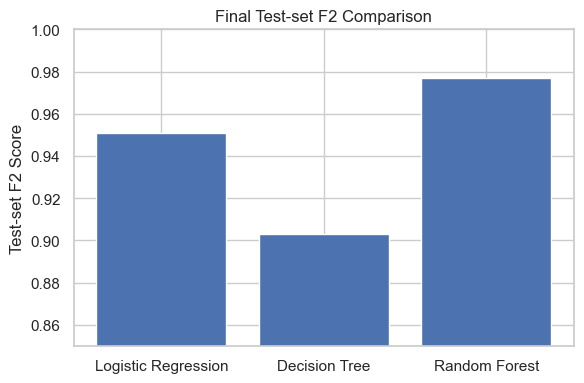

In [28]:
final_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'F2': [0.951, 0.903, 0.977]
})

plt.figure(figsize=(6,4))
plt.bar(final_df['Model'], final_df['F2'])
plt.ylabel('Test-set F2 Score')
plt.ylim(0.85, 1.0)
plt.title('Final Test-set F2 Comparison')
plt.tight_layout()
plt.show()

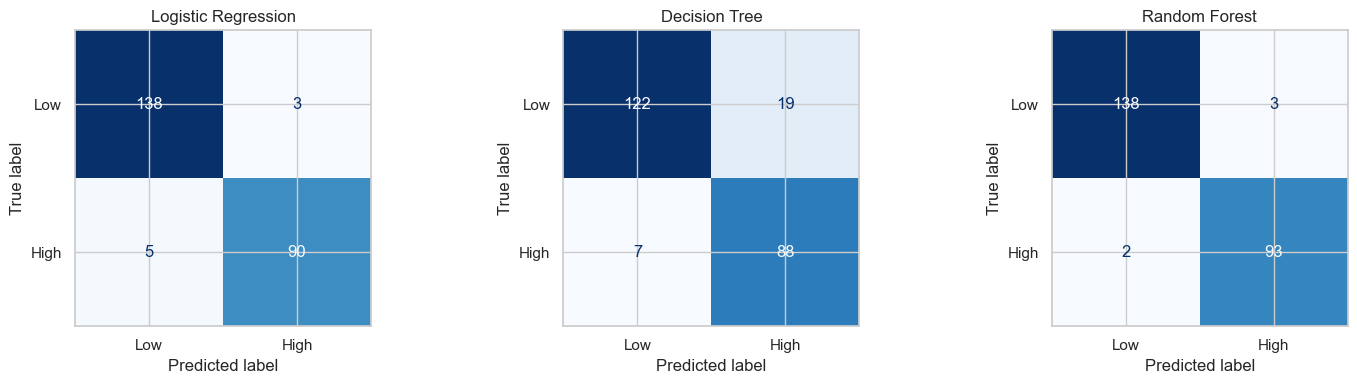

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ("Logistic Regression", y_pred_lr),
    ("Decision Tree", y_pred_tree),
    ("Random Forest", y_pred_rf)
]

for ax, (name, preds) in zip(axes, models):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Low", "High"]
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

These confusion matrices emphasise once again the strength of the random forest model. Using the testing dataset, 2 patients that were high risk were classified by the model as low risk (false negative), while 3 patients who were actually low risk were classified as high risk. This means that approximately 0.8% of the predictions were false negatives, while 1.3% were false positives.

### Wilcoxon signed-rank across the 5 paired fold scores

This test assesses whether the differences between the models are meaningful. This is particularly important given the small size of the dataset. 

In [30]:
def get_fold_scores(grid_search_obj):
    idx = grid_search_obj.best_index_
    results = grid_search_obj.cv_results_
    n_splits = grid_search_obj.cv.get_n_splits()
    return np.array([results[f'split{i}_test_score'][idx] for i in range(n_splits)])

results_tree_df = pd.DataFrame(grid_search_tree.cv_results_)
match = results_tree_df[
    (results_tree_df['param_clf__max_depth'] == 3) &
    (results_tree_df['param_clf__min_samples_leaf'] == 10) &
    (results_tree_df['param_clf__criterion'] == 'gini') &
    (results_tree_df['param_clf__class_weight'] == 'balanced')
]

print(match[['params', 'mean_test_score']])
final_tree_idx = match.index[0]

tree_fold_scores = np.array([
    grid_search_tree.cv_results_[f'split{i}_test_score'][final_tree_idx]
    for i in range(5)
])

lr_fold_scores = get_fold_scores(grid_search)
rf_fold_scores = get_fold_scores(grid_search_rf)

print("LR folds:  ", lr_fold_scores)
print("Tree folds:", tree_fold_scores)
print("RF folds:  ", rf_fold_scores)

                                                                                                          params  \
6  {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_leaf': 10}   

   mean_test_score  
6         0.924322  
LR folds:   [0.97560976 0.97855228 0.98143236 0.95945946 0.95303867]
Tree folds: [0.90909091 0.96103896 0.93085106 0.91280654 0.90782123]
RF folds:   [0.98382749 0.97593583 0.98404255 0.97855228 0.98360656]


In [31]:
stat_rf_tree, p_rf_tree = stats.wilcoxon(rf_fold_scores, tree_fold_scores)
print(f"RF vs Tree: statistic={stat_rf_tree:.3f}, p={p_rf_tree:.4f}")
print("RF beat Tree in", (rf_fold_scores > tree_fold_scores).sum(), "of 5 folds")

stat_lr_tree, p_lr_tree = stats.wilcoxon(lr_fold_scores, tree_fold_scores)
print(f"LR vs Tree: statistic={stat_lr_tree:.3f}, p={p_lr_tree:.4f}")
print("LR beat Tree in", (lr_fold_scores > tree_fold_scores).sum(), "of 5 folds")

stat_rf_lr, p_rf_lr = stats.wilcoxon(rf_fold_scores, lr_fold_scores)
print(f"RF vs LR: statistic={stat_rf_lr:.3f}, p={p_rf_lr:.4f}")
print("RF beat LR in", (rf_fold_scores > lr_fold_scores).sum(), "of 5 folds")

RF vs Tree: statistic=0.000, p=0.0625
RF beat Tree in 5 of 5 folds
LR vs Tree: statistic=0.000, p=0.0625
LR beat Tree in 5 of 5 folds
RF vs LR: statistic=2.000, p=0.1875
RF beat LR in 4 of 5 folds


Both Logistic Regression and the Random Forest models significantly outperformed the Single Tree model, as can be seen for the wilcoxon test values above (and the lowest possible mesure of p value available for this test).

Random Forest does outperform Logistic Regression (and does so in 4 out of 5 folds), but this difference is not signficant with a p-value of 0.1875. It is possible that given a bigger sample size that the difference would be significant, but with the available evidence, we cannot reject the null hypothesis of similarly performing models.

Given some of the benefits of a more parsimonious model, balancing the marginally stronger performance of the random forests model against the more explainable, simpler logistic regression model is important.

# Explanability: SHAP Evaluation of the Random Forest Model

As described in the documentation, "SHAP makes transparent the correlations picked up by predictive ML models". This is particularly valuable in a clinical context so that clinicians and patients can understand the influence of different features on risk level. Therefore, an SHAP evaluation will be conducted here on the Random Forest model to make it more comprehensible and identify the most important features for replicating risk level classification.

In [32]:
rf_model = best_rf.named_steps['clf']

background = shap.sample(X_trainval, 100, random_state=42)
explainer = shap.TreeExplainer(rf_model, background)

shap_values = explainer.shap_values(X_test)

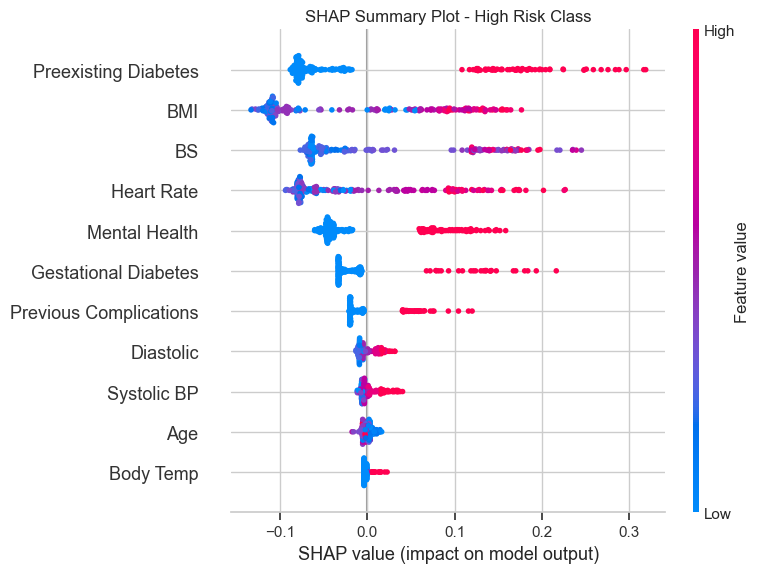

In [33]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    show=False
)

plt.title('SHAP Summary Plot - High Risk Class')
plt.tight_layout()
plt.show()

This summary plot triangulates well with the findings in the exploratory analysis as well as the construction of the single tree model. The single most important feature in classifying risk level is prexisting diabetes. Patients with diabetes are clustered showing having a positive impact on classification as high risk, while patients without preexisting diabetest are even more closely clustered on the negative side.

BMI has the second strongest impact in the random forest model, with a higher BMI correlating with a greater probability of being classified as a high risk pregnancy, and lower BMI correlating with being in a low risk category.

Blood sugar also has a strong effect, which is consistent with the construction of the single decision tree model.

Although the values are more spread out, heart rate also has a meaningful effect on risk level. This could be as it may be a proxy for general cardiovascular health and fitness.

The binary mental health feature shows a clear separation, with presence of the condition (red) pushing predictions toward high risk. Absence (blue) pushes predictions toward low risk. As with blood sugar, this was also raised in previous exploration and modelling, and is of interest also as it indicates the model is using psychosocial information in addition to physiological variables.

Both Gestational Diabetes and Previous Complications show positive SHAP values when present, indicating that they contribute to higher predicted risk.

Systolic and diastolic blood pressure contribute, but their SHAP ranges are much smaller than those of diabetes-related features, indicating that they are of less importance in constructing a risk classification model.

Age and Body temperature show tight clustering around zero, suggesting that they contributed little towards the model, which is interesting considering the emphasis given both clinically and socially to 'geriatric pregnancies' (pregnancies in women aged over 35) and pregnancy in older women.


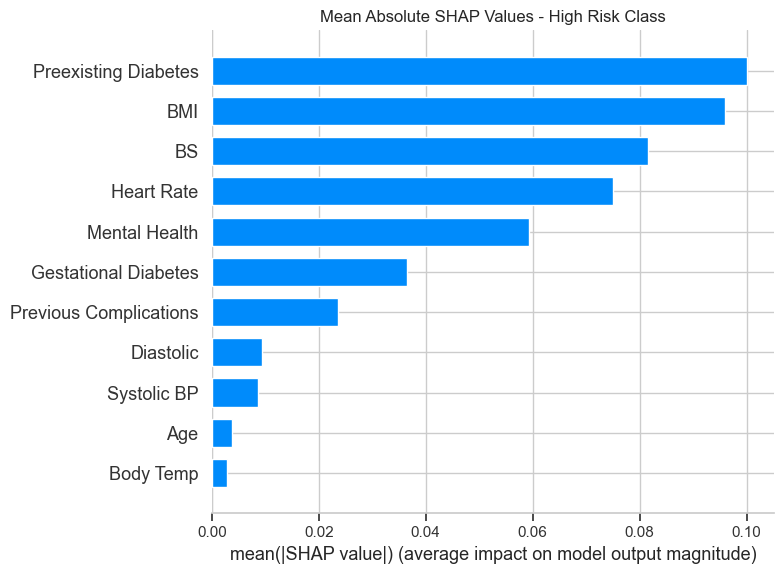

In [34]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    plot_type='bar',
    show=False
)

plt.title('Mean Absolute SHAP Values - High Risk Class')
plt.tight_layout()
plt.show()

## Explainability of Logistic Regression Model

SHAP is less necessary for the logistic regression, as we can look directly at the coefficients, so this model is already more explainable.

In [35]:
lr_model = best_model.named_steps['clf']

coef_df = pd.DataFrame({
    'Feature': X_trainval.columns,
    'Coefficient': lr_model.coef_[0]
})

# Odds ratios
coef_df['OddsRatio'] = np.exp(coef_df['Coefficient'])

# Absolute importance
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()

coef_df = coef_df.sort_values('AbsCoefficient', ascending=False)

coef_df.round(3)

,Feature,Coefficient,OddsRatio,AbsCoefficient
7,Preexisting Diabetes,1.583,4.868,1.583
8,Gestational Diabetes,1.232,3.427,1.232
9,Mental Health,0.884,2.420,0.884
3,BS,0.732,2.080,0.732
10,Heart Rate,0.709,2.032,0.709
6,Previous Complications,0.691,1.996,0.691
5,BMI,0.553,1.739,0.553
2,Diastolic,0.427,1.532,0.427
0,Age,-0.389,0.677,0.389
4,Body Temp,0.320,1.378,0.320


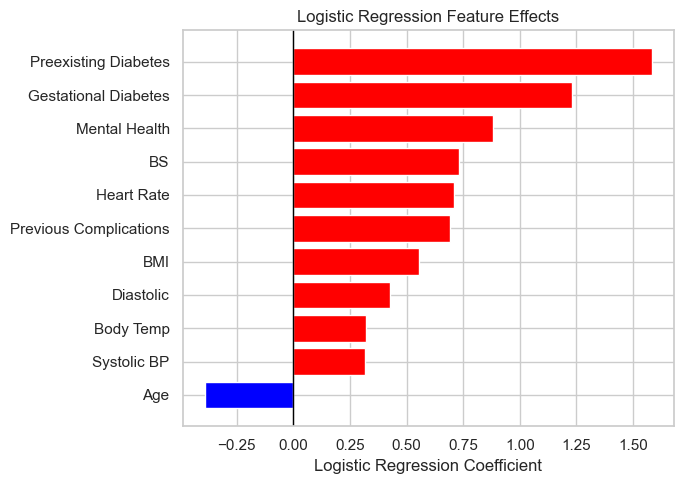

In [36]:
plot_df = coef_df.sort_values('Coefficient')

plt.figure(figsize=(7,5))
colors = ['red' if x > 0 else 'blue' for x in plot_df['Coefficient']]

plt.barh(plot_df['Feature'], plot_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=1)

plt.xlabel('Logistic Regression Coefficient')
plt.title('Logistic Regression Feature Effects')

plt.tight_layout()
plt.show()

## Error Analysis

The confusion matrices are already done above, and indicate the number of false negatives and false positives.



In [37]:
# RF false negatives
print("--- RF False Negatives ---")
fn_idx = X_test[(y_test == 1) & (y_pred_rf == 0)].index

false_negatives = test_df.loc[fn_idx]

print(false_negatives)
print(f"Number of false negatives: {len(false_negatives)}")

print("--- LR False Negatives ---")
fn_idx_lr = X_test[(y_test == 1) & (y_pred_lr == 0)].index

false_negatives_lr = test_df.loc[fn_idx_lr]

print(false_negatives_lr)
print(f"Number of LR false negatives: {len(false_negatives_lr)}")

print("--- Single Tree False Negatives ---")
fn_idx_tree = X_test[(y_test == 1) & (y_pred_tree == 0)].index

false_negatives_tree = test_df.loc[fn_idx_tree]

print(false_negatives_tree)
print(f"Number of Tree false negatives: {len(false_negatives_tree)}")

--- RF False Negatives ---
     Age  Systolic BP  Diastolic   BS  Body Temp   BMI  \
200   26        120.0       90.0  6.7         98  23.9   
232   17         85.0       60.0  6.0        102  17.0   

     Previous Complications  Preexisting Diabetes  Gestational Diabetes  \
200                     0.0                   0.0                     1   
232                     1.0                   0.0                     0   

     Mental Health  Heart Rate Risk Level  
200              0        58.0       High  
232              0        62.0       High  
Number of false negatives: 2
--- LR False Negatives ---
     Age  Systolic BP  Diastolic   BS  Body Temp   BMI  \
19    30        120.0       80.0  9.0         98  30.0   
88    29        140.0       90.0  8.0        101  27.0   
200   26        120.0       90.0  6.7         98  23.9   
221   21        100.0       65.0  5.8         98  24.5   
232   17         85.0       60.0  6.0        102  17.0   

     Previous Complications  Preexi

The above reporting of the missed cases by model give some interesting insights. The Random Forest model missed two cases which were labelled as high risk. However, these cases were arguably unusual. They did not have preexisting diabetes, blood sugar was relatively normal, and BMI was not very high, and therefore the metabolic markers for high risk were not present in these two cases.

The Logistic Regression model missed these same two cases and three additional cases, each of which had a feature which a clinician might have raised a concern about (e.g. high BMI, high BS/BP, Previous Complications and Mental Health). 

The Single Tree model missed seven cases, each also with features that a clinician would be concerned about (elevated blood sugar and or blood pressure, gestational diabetes, mental health issues etc.)

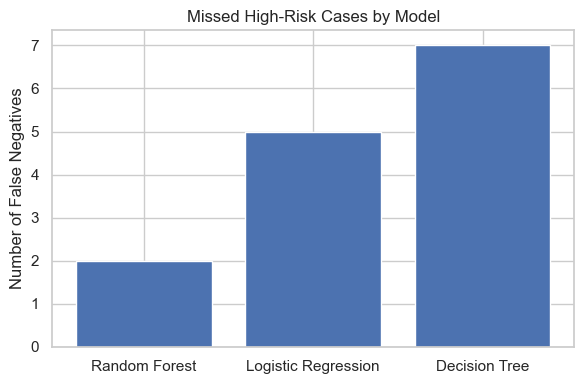

In [39]:
fn_summary = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression', 'Decision Tree'],
    'False Negatives': [2, 5, 7]
})

plt.figure(figsize=(6,4))
plt.bar(fn_summary['Model'], fn_summary['False Negatives'])
plt.ylabel('Number of False Negatives')
plt.title('Missed High-Risk Cases by Model')
plt.tight_layout()
plt.show()

# Reviewing Subgroups

As was raised in Assignment 1, one of the areas of interest is in the different outcomes in different subgroups such as ethnicity, age, and deprivation level. While deprivation level and ethnicity are not reported in this dataset, an age analysis looking at how well each model performs in different age groups would be of interest.

In [38]:
test_df_eval = test_df.copy()
test_df_eval['y_true'] = y_test.values
test_df_eval['y_pred'] = y_pred_rf

test_df_eval['AgeGroup'] = pd.cut(
    test_df_eval['Age'],
    bins=[0, 24, 29, 34, 50],
    labels=['<25', '25-29', '30-34', '35+']
)

fn_rate = test_df_eval.groupby('AgeGroup').apply(
    lambda g: ((g['y_true'] == 1) & (g['y_pred'] == 0)).sum() /
              (g['y_true'] == 1).sum()
)

print(" Random Forest model examining missed cases by age group:")
print(fn_rate)

 Random Forest model examining missed cases by age group:
AgeGroup
<25      0.030303
25-29    0.047619
30-34    0.000000
35+      0.000000
dtype: float64


/var/folders/hc/5z1l136x7b12q7qzw10d_3kw0000gn/T/ipykernel_1367/2491249670.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fn_rate = test_df_eval.groupby('AgeGroup').apply(
/var/folders/hc/5z1l136x7b12q7qzw10d_3kw0000gn/T/ipykernel_1367/2491249670.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fn_rate = test_df_eval.groupby('AgeGroup').apply(


As previously identified, false negative rates for the Random Forest model were low across all age groups. The missed high risk cases occurred only in the younger age categories (<25 years: 3.0%; 25–29 years: 4.8%), whereas no false negatives were observed in women aged 30–34 years or 35 years and older. Because the number of high-risk cases within each subgroup was small, these differences should be interpreted cautiously and do not provide strong evidence of age related performance disparities. The findings suggest that the remaining Random Forest errors were concentrated in a small number of younger patients with relatively subtle risk profiles.

## Comparison with NHS Aggregate statistics

This comparision is only really relevant for the Age feature. As risk level is not directly reported, it is considered by proxy via two measures: birth status (live vs. stillbirth), and length of postnatal stay. 

In [43]:
status_df = pd.read_csv("./NHS_birth_status_by_age.csv")
postnatal_stay_df = pd.read_csv("./NHS_postnatal_stays_by_age.csv")

status_df.head()


,Age groups,Total deliveries,Unknown,Total excl. unknown,Live birth,Still birth,Unnamed: 6
0,Total,"542,235",15.7%,"456,857",99.6%,0.4%,NaN
1,14 and under,92,27.2%,67,98.5%,1.5%,NaN
2,15-19,"11,640",15.3%,"9,860",99.5%,0.5%,NaN
3,20-24,"59,817",15.2%,"50,745",99.6%,0.4%,NaN
4,25-29,"134,348",15.2%,"113,860",99.7%,0.3%,NaN


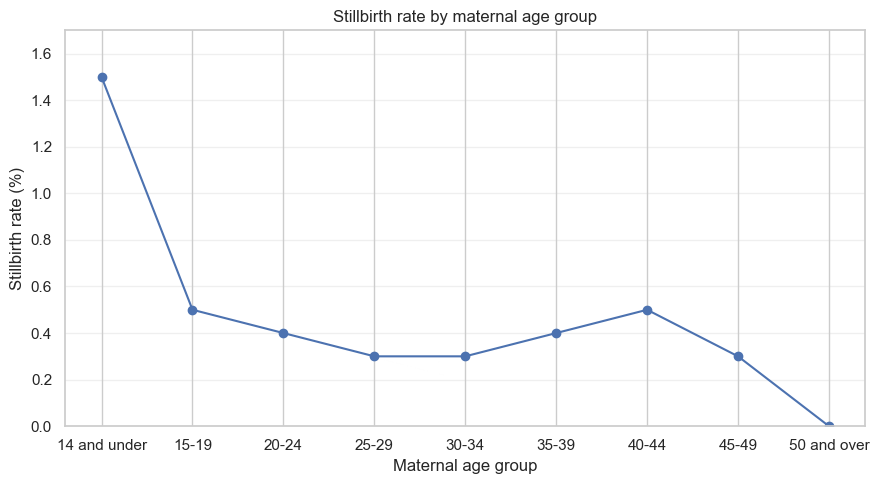

In [46]:
status_plot_df = status_df.copy()

status_plot_df = status_plot_df[~status_plot_df['Age groups'].isin(['Total', 'Unknown'])]

status_plot_df['Still birth'] = status_plot_df['Still birth'].str.rstrip('%').astype(float)

plt.figure(figsize=(9,5))
plt.plot(status_plot_df['Age groups'], status_plot_df['Still birth'], marker='o')

plt.ylabel('Stillbirth rate (%)')
plt.xlabel('Maternal age group')
plt.title('Stillbirth rate by maternal age group')
plt.ylim(0, max(status_plot_df['Still birth']) + 0.2)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

While this graph appears to confirm the negative effect of Age on risk level proposed by the models in this analysis, it is important to note that in actual figures, this trend is unlikely to be statistically significant. Even though these are national figures, the rates of stillbirths are thankfully so low, as well as the rates of pregnancy and birth in mothers aged under 14, that the apparent 1.5% stillbirth rate in mothers under 14 is driven by one single case. 

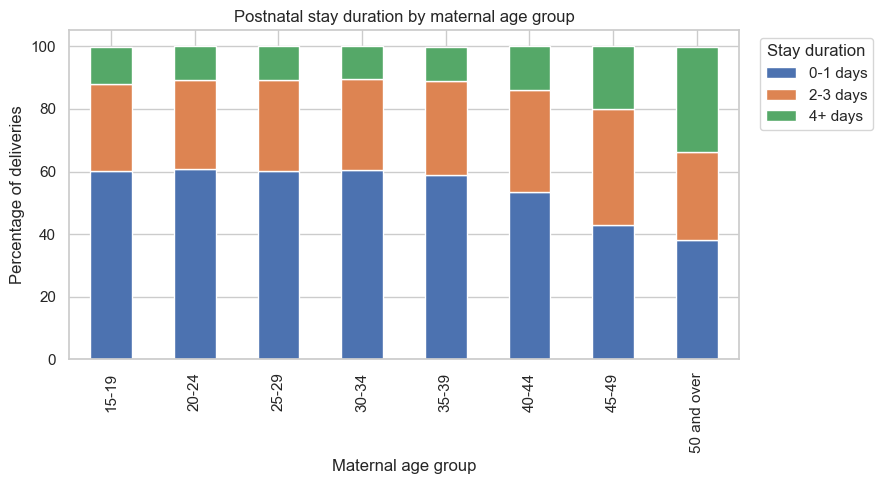

In [48]:
plot_df = postnatal_stay_df.copy()

plot_df = plot_df[~plot_df['Age groups'].isin(['Total', 'Unknown', '14 and under'])]


cols = ['Same Day','1 Day','2 Days','3 Days','4 Days',
        '5 Days','6 Days','7 Plus Days']

for c in cols:
    plot_df[c] = plot_df[c].str.rstrip('%').astype(float)

# Categorise
plot_df['0-1 days'] = plot_df['Same Day'] + plot_df['1 Day']
plot_df['2-3 days'] = plot_df['2 Days'] + plot_df['3 Days']
plot_df['4+ days'] = (
    plot_df['4 Days'] + plot_df['5 Days'] +
    plot_df['6 Days'] + plot_df['7 Plus Days']
)

plot_df = plot_df[['Age groups','0-1 days','2-3 days','4+ days']]

# Plot
plot_df.set_index('Age groups').plot(
    kind='bar',
    stacked=True,
    figsize=(9,5)
)

plt.ylabel('Percentage of deliveries')
plt.xlabel('Maternal age group')
plt.title('Postnatal stay duration by maternal age group')
plt.legend(title='Stay duration', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

This graph presents a trend that aligns more with what is clinically expected, although it does conflict with the predictions of the model from this analysis. Duration of postnatal stay appears to be relatively stable until aged 40, and then it increases with age, indicating a more complicated birth or postnatal health picture that would align with higher risk level.